# Dataset Creation

Downloads airfoil geometries from the UIUC Airfoil Database, resamples to a
fixed-length coordinate vector, runs XFOIL to generate CL and CD labels across a range
of operating conditions, and saves the clean dataset for training.

**Outputs:**
- `airfoil_dataset_raw.pkl`: all raw coordinate files
- `airfoil_dataset_labeled.pkl`: final labeled dataset (geometry + AoA + Re -> CL, CD)
- `dataset_stats.json`: summary statistics


In [ ]:
!apt-get install -y xfoil xvfb > /dev/null 2>&1
!pip install -q requests beautifulsoup4 numpy pandas scipy matplotlib tqdm

In [ ]:
import subprocess

result = subprocess.run(['which', 'xfoil'], capture_output=True, text=True)
if result.returncode == 0:
    print(f'XFOIL found at: {result.stdout.strip()}')
else:
    print('XFOIL not found via apt — attempting manual install...')
    !wget -q https://web.mit.edu/drela/Public/web/xfoil/xfoil6.99.tgz -O xfoil.tgz
    !tar xzf xfoil.tgz
    print('Manual install attempted. Check /content for xfoil binary.')


XFOIL found at: /usr/bin/xfoil


In [ ]:
import json
import logging
import pickle
import shutil
import subprocess
import tempfile
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
from scipy import interpolate
from tqdm.auto import tqdm

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)s %(message)s',
    datefmt='%H:%M:%S',
)
_LOG = logging.getLogger(__name__)

np.random.seed(42)

_OUTPUT_DIR = Path('/content/airfoil_data')
_COORD_DIR = _OUTPUT_DIR / 'coordinates'
_CHECKPOINT_FILE = _OUTPUT_DIR / 'xfoil_checkpoint.pkl'
_LABEL_FILE = _OUTPUT_DIR / 'airfoil_dataset_labeled.pkl'
_RAW_FILE = _OUTPUT_DIR / 'airfoil_dataset_raw.pkl'
_DRIVE_DIR = Path('/content/drive/MyDrive/airfoil_surrogate')

_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
_COORD_DIR.mkdir(exist_ok=True)

# XFOIL can't handle paths that contain spaces
_XFOIL_COORD_DIR = Path('/content/xfoil_coords')
if not _XFOIL_COORD_DIR.exists():
    _XFOIL_COORD_DIR.symlink_to(_COORD_DIR.resolve())
    print(f'Created symlink {_XFOIL_COORD_DIR} → {_COORD_DIR}')
else:
    print(f'Symlink already exists: {_XFOIL_COORD_DIR}')

_UIUC_INDEX_URL = 'https://m-selig.ae.illinois.edu/ads/coord_database.html'
_UIUC_BASE_URL = 'https://m-selig.ae.illinois.edu/ads/coord/'

_MAX_AIRFOILS = 2000

#geometry resampling
_N_POINTS = 200  #200 (x, y) pairs, 400-dim geometry vector

_AOA_VALUES: list[float] = np.arange(-4, 18, 2).tolist()  # -4°..16° step 2°
_RE_VALUES: list[float] = [500_000, 1_000_000, 2_000_000]
_MACH = 0.0
_NCRIT = 9
_XFOIL_ITER = 100  #max newton iterations per operating point
_XFOIL_TIMEOUT = 30  #seconds before a hung XFOIL call is killed.

_CHECKPOINT_INTERVAL = 50
_DOWNLOAD_WORKERS = 16  #concurrent outbound connections

print(
    f'Config: {_MAX_AIRFOILS} airfoils, '
    f'{len(_AOA_VALUES) * len(_RE_VALUES)} XFOIL calls each, '
    f'checkpoint every {_CHECKPOINT_INTERVAL}.')


Created symlink /content/xfoil_coords → /content/airfoil_data/coordinates
Config: 2000 airfoils, 33 XFOIL calls each, checkpoint every 50.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')
_DRIVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Drive mounted. Checkpoints will be mirrored to {_DRIVE_DIR}')


Mounted at /content/drive
Drive mounted. Checkpoints will be mirrored to /content/drive/MyDrive/airfoil_surrogate


Download UIUC Airfoil Coordinate Files

In [ ]:
def fetch_airfoil_list(index_url: str) -> list[dict[str, str]]:
    """Scrape the UIUC index page for .dat file links.

    Args:
        index_url: URL of the UIUC coordinate database index page.

    Returns:
        List of dicts, each with keys 'name' (stem) and 'url' (full .dat URL).

    Raises:
        requests.HTTPError: If the index page cannot be fetched.
    """
    resp = requests.get(index_url, timeout=30)
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, 'html.parser')
    airfoils = []
    for link in soup.find_all('a', href=True):
        href = link['href']
        if href.endswith('.dat') and 'coord/' in href:
            name = Path(href).stem
            full_url = _UIUC_BASE_URL + Path(href).name
            airfoils.append({'name': name, 'url': full_url})
    return airfoils


def _download_one(name: str, url: str, dest_dir: Path) -> tuple[str, Path | None]:
    """Download a single .dat file; return (name, path) or (name, None) on error.

    Args:
        name: Airfoil stem name used for the local filename.
        url: Remote URL of the .dat coordinate file.
        dest_dir: Local directory to write the file into.

    Returns:
        Tuple of (name, local Path) on success, or (name, None) on failure.
    """
    dest = dest_dir / f'{name}.dat'
    if dest.exists():
        return name, dest  #already downloaded, skip
    try:
        resp = requests.get(url, timeout=15)
        resp.raise_for_status()
        dest.write_text(resp.text)
        return name, dest
    except requests.RequestException as exc:
        _LOG.debug('Download failed for %s: %s', name, exc)
        return name, None


def download_airfoils(
    airfoil_list: list[dict[str, str]],
    dest_dir: Path,
    max_workers: int = _DOWNLOAD_WORKERS,
) -> list[dict]:
    """Download .dat files in parallel using a thread pool.

    Args:
        airfoil_list: List of dicts with 'name' and 'url' keys.
        dest_dir: Directory to write downloaded files into.
        max_workers: Number of concurrent download threads.

    Returns:
        List of dicts with keys 'name', 'path' (Path or None), and 'ok' (bool).
    """
    results: list[dict] = []
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {
            pool.submit(_download_one, a['name'], a['url'], dest_dir): a['name']
            for a in airfoil_list
        }
        for future in tqdm(
            as_completed(futures), total=len(futures), desc='Downloading'
        ):
            name, path = future.result()
            results.append({'name': name, 'path': path, 'ok': path is not None})
    return results


_LOG.info('Fetching UIUC airfoil index...')
_all_airfoils = fetch_airfoil_list(_UIUC_INDEX_URL)
_LOG.info('Found %d airfoil files on UIUC database.', len(_all_airfoils))

np.random.shuffle(_all_airfoils)
_selected = _all_airfoils[:_MAX_AIRFOILS]
_LOG.info('Selected %d airfoils for this run.', len(_selected))

_download_results = download_airfoils(_selected, _COORD_DIR)
_ok_count = sum(r['ok'] for r in _download_results)
print(f'Downloaded: {_ok_count}/{len(_selected)}')


Downloading:   0%|          | 0/1585 [00:00<?, ?it/s]

Downloaded: 1585/1585


In [ ]:
def parse_dat_file(path: Path) -> np.ndarray | None:
    """Parse a UIUC .dat file into a raw (N, 2) coordinate array.

    Handles Selig format (CCW from trailing edge) and Lednicer format
    (upper surface then lower surface).  Returns coordinates in the order
    they appear in the file after stripping header lines; downstream
    resampling is order-agnostic.

    Args:
        path: Path to the .dat coordinate file.

    Returns:
        Float array of shape (N, 2) with chord-normalised (x, y) coordinates,
        or None when the file cannot be parsed or contains fewer than 20 points.
    """
    try:
        text = path.read_text(errors='replace')
    except OSError as exc:
        _LOG.debug('Cannot read %s: %s', path, exc)
        return None

    coords: list[tuple[float, float]] = []
    lednicer_skip_done = False
    for line in text.strip().splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        parts = line.split()
        if len(parts) != 2:
            continue
        try:
            x, y = float(parts[0]), float(parts[1])
        except ValueError:
            continue
        # Lednicer format files have a header line like "35.    35." that gives
        # the number of upper/lower surface points.  Both values are >= 2 and
        # clearly not airfoil coordinates.  Skip exactly one such line.
        if not lednicer_skip_done and x >= 2.0 and y >= 2.0:
            lednicer_skip_done = True
            continue
        coords.append((x, y))

    if len(coords) < 20:
        return None

    arr = np.array(coords)

    # Normalise to unit chord when the file uses actual dimensions (0-100 range
    # or similar) rather than normalised x/c in [0, 1].
    x_range = arr[:, 0].max() - arr[:, 0].min()
    if x_range > 1.5 or x_range < 0.5:
        arr[:, 0] = (arr[:, 0] - arr[:, 0].min()) / x_range
        arr[:, 1] = arr[:, 1] / x_range

    # Sanity check: after normalisation y values for a real airfoil should be
    # well within [-0.6, 0.6].  Anything outside suggests a corrupt file.
    if arr[:, 1].max() > 0.6 or arr[:, 1].min() < -0.6:
        return None

    return arr


def resample_airfoil(coords: np.ndarray, n: int = _N_POINTS,) -> np.ndarray | None:
    """Resample an airfoil contour to n arc-length-uniform points.

    Args:
        coords: Float array of shape (M, 2) with raw (x, y) coordinates.
        n: Number of output sample points.

    Returns:
        Flattened float32 array of shape (2*n,) containing interleaved
        resampled x and y coordinates, or None when interpolation fails.
    """
    if coords is None or len(coords) < 4:
        return None

    diffs = np.diff(coords, axis=0)
    seg_lengths = np.hypot(diffs[:, 0], diffs[:, 1])
    arc = np.concatenate([[0.0], np.cumsum(seg_lengths)])
    if arc[-1] == 0:
        return None
    arc /= arc[-1]  # Normalise to [0, 1].

    # Drop duplicate arc-length values required by interp1d.
    _, unique_idx = np.unique(arc, return_index=True)
    arc_u = arc[unique_idx]
    coords_u = coords[unique_idx]
    if len(arc_u) < 4:
        return None

    try:
        fx = interpolate.interp1d(arc_u, coords_u[:, 0], kind='linear', fill_value='extrapolate')
        fy = interpolate.interp1d(arc_u, coords_u[:, 1], kind='linear', fill_value='extrapolate')
    except ValueError as exc:
        _LOG.debug('interp1d failed: %s', exc)
        return None

    t_new = np.linspace(0, 1, n)
    return np.stack([fx(t_new), fy(t_new)], axis=1).flatten().astype(np.float32)


def build_geometry_records(download_results: list[dict],) -> tuple[list[dict], int]:
    """Parse and resample all successfully downloaded airfoils.

    Args:
        download_results: Output of download_airfoils().

    Returns:
        Tuple of (records, n_errors) where records is a list of dicts with
        keys 'name', 'coords' (shape 2*N_POINTS), and 'n_original_pts'.
    """
    records: list[dict] = []
    n_errors = 0
    for r in tqdm(download_results, desc='Parsing & resampling'):
        if not r['ok']:
            continue
        raw = parse_dat_file(r['path'])
        resampled = resample_airfoil(raw)
        if resampled is None:
            n_errors += 1
            continue
        records.append({
            'name': r['name'],
            'coords': resampled,
            'n_original_pts': len(raw),
        })
    return records, n_errors


_airfoil_records, _parse_errors = build_geometry_records(_download_results)
print(f'Parsed: {len(_airfoil_records)}  failures: {_parse_errors}')

with open(_RAW_FILE, 'wb') as f:
    pickle.dump(_airfoil_records, f)
shutil.copy(_RAW_FILE, _DRIVE_DIR / _RAW_FILE.name)
print(f'Raw geometry saved → {_RAW_FILE} (mirrored to Drive)')


Parsing & resampling:   0%|          | 0/1585 [00:00<?, ?it/s]

Parsed: 1585  failures: 0
Raw geometry saved → /content/airfoil_data/airfoil_dataset_raw.pkl (mirrored to Drive)


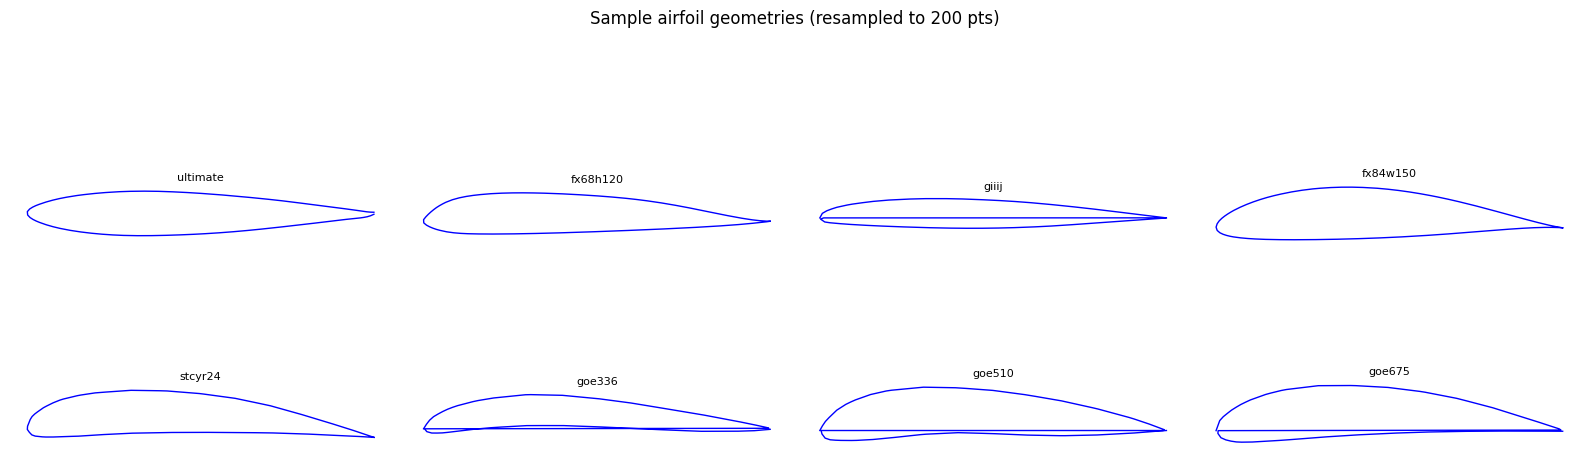

Airfoil visualisation saved.


In [ ]:
def plot_sample_airfoils(
    records: list[dict],
    n_points: int = _N_POINTS,
    save_path: Path | None = None,
) -> None:
    """Plot a random sample of resampled airfoil contours.

    Args:
        records: List of geometry record dicts (must contain 'name' and 'coords').
        n_points: Number of sample points per contour (used for reshape).
        save_path: If provided, save the figure to this path.
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    axes = axes.flatten()
    idxs = np.random.choice(len(records), size=min(8, len(records)), replace=False)
    for ax, idx in zip(axes, idxs):
        rec = records[idx]
        xy = rec['coords'].reshape(-1, 2)
        ax.plot(xy[:, 0], xy[:, 1], 'b-', linewidth=1)
        ax.set_aspect('equal')
        ax.set_title(rec['name'], fontsize=8)
        ax.axis('off')
    plt.suptitle(f'Sample airfoil geometries (resampled to {n_points} pts)', fontsize=12)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    plt.show()


plot_sample_airfoils(_airfoil_records, save_path=_OUTPUT_DIR / 'sample_airfoils.png')
print('Airfoil visualisation saved.')


XFOIL Label Generation

For each airfoil, the following is swept:
- **Angles of Attack (AoA):** -4° to 16° in steps of 2°  
- **Reynolds Numbers:** 500 k, 1 M, 2 M  

This gives up to 11 × 3 = 33 (AoA, Re) pairs per airfoil.


In [ ]:
import os
import re as _re


def run_xfoil(
    name: str,
    coord_path: Path,
    aoa: float,
    re: float,
    ncrit: int = _NCRIT,
    max_iter: int = _XFOIL_ITER,
    timeout: int = _XFOIL_TIMEOUT,
) -> dict[str, float] | None:
    """Run XFOIL for one airfoil at a single (AoA, Re) operating condition.

    Parses CL/CD/CM from XFOIL stdout rather than from a polar accumulation
    file.  This avoids the SIGFPE crash that the apt-packaged XFOIL 6.99
    produces when its PGPLOT backend tries to render after convergence.

    Args:
        name: Airfoil name (truncated to 8 chars for XFOIL's internal label).
        coord_path: Path to the .dat coordinate file.
        aoa: Angle of attack in degrees.
        re: Reynolds number.
        ncrit: Transition N-crit parameter.
        max_iter: Maximum Newton iterations for the viscous solver.
        timeout: Seconds before the subprocess is killed.

    Returns:
        Dict with keys 'CL', 'CD', 'CM' when XFOIL converges and the result
        passes physical plausibility checks, otherwise None.

    Raises:
        RuntimeError: If the xfoil binary cannot be found on PATH.
    """
    # No PACC block — we parse stdout directly, sidestepping the PGPLOT
    # SIGFPE crash that occurs when the apt binary tries to plot after PACC.
    xfoil_input = (
        f'LOAD {coord_path}\n'
        f'{name[:8]}\n'
        'PLOP\n'
        'G\n'   # toggle graphics off (belt-and-suspenders with xvfb-run)
        '\n'
        'PANE\n'
        'OPER\n'
        f'VISC {re:.0f}\n'
        f'MACH {_MACH}\n'
        f'ITER {max_iter}\n'
        f'VPAR\nN {ncrit}\n\n'
        f'ALFA {aoa:.2f}\n'
        'QUIT\n'
    )
    try:
        proc = subprocess.run(
            ['xvfb-run', '-a', 'xfoil'],
            input=xfoil_input,
            capture_output=True,
            text=True,
            timeout=timeout,
            check=False,
            env={k: v for k, v in os.environ.items() if k != 'DISPLAY'},
        )
    except subprocess.TimeoutExpired:
        return None
    except FileNotFoundError as exc:
        raise RuntimeError(
            'xfoil binary not found on PATH. Ensure it is installed.'
        ) from exc

    stdout = proc.stdout

    # XFOIL prints converged values like:
    #   "       a =  4.000      CL =  1.0140"
    #   "      Cm = -0.1389     CD =  0.00844   =>   CDf =  0.00416 ..."
    # CD regex uses a negative lookahead so it doesn't accidentally match CDf or CDp
    cl_match = _re.search(r'\bCL\s*=\s*([-+]?\d+\.\d+)', stdout)
    cd_match = _re.search(r'\bCD(?![fp])\s*=\s*([-+]?\d+\.\d+)', stdout)
    cm_match = _re.search(r'\bCm\s*=\s*([-+]?\d+\.\d+)', stdout)

    if not (cl_match and cd_match and cm_match):
        return None  # did not converge or xfoil error

    try:
        cl = float(cl_match.group(1))
        cd = float(cd_match.group(1))
        cm = float(cm_match.group(1))
    except ValueError:
        return None

    # Physical plausibility filter.
    if cd <= 0 or abs(cl) > 4.0 or cd > 1.0:
        return None

    return {'CL': cl, 'CD': cd, 'CM': cm}


print('XFOIL runner defined.')

#test before the full run
_test = _airfoil_records[0]
_test_path = _XFOIL_COORD_DIR / f"{_test['name']}.dat"
print(f"Smoke-test on: {_test['name']}")
_smoke = run_xfoil(_test['name'], _test_path, aoa=5.0, re=1_000_000)
if _smoke:
    print(f"  AoA=5°, Re=1M → CL={_smoke['CL']:.4f}, CD={_smoke['CD']:.6f}")
else:
    print('  XFOIL did not converge on smoke-test. Check installation.')


XFOIL runner defined.
Smoke-test on: fx75193
  AoA=5°, Re=1M → CL=1.2106, CD=0.004970


In [ ]:
test_cases = [
    ('naca2412', 4.0, 1_000_000),
    ('naca4412', 4.0, 1_000_000),
    (_airfoil_records[0]['name'], 4.0, 1_000_000),
    (_airfoil_records[1]['name'], 4.0, 1_000_000),
    (_airfoil_records[2]['name'], 4.0, 1_000_000),
]

# First confirm the DISPLAY fix is actually active in this kernel
import inspect
src = inspect.getsource(run_xfoil)
print("DISPLAY fix active:", "'DISPLAY'" in src)
print()

for name, aoa, re in test_cases:
    path = _XFOIL_COORD_DIR / f'{name}.dat'
    if not path.exists():
        print(f'  {name}: .dat file not found, skipping')
        continue
    result = run_xfoil(name, path, aoa=aoa, re=re)
    print(f'  {name} AoA={aoa}: {result}')

DISPLAY fix active: True

  naca2412 AoA=4.0: None
  naca4412 AoA=4.0: None
  fx75193 AoA=4.0: {'CL': 1.0746, 'CD': 0.00495, 'CM': -0.1224}
  e656 AoA=4.0: None
  hq09 AoA=4.0: None


In [ ]:
import os, re as _re, subprocess

rec = _airfoil_records[0]
coord_path = _XFOIL_COORD_DIR / f"{rec['name']}.dat"

xfoil_input = (
    f'LOAD {coord_path}\n'
    f'{rec["name"][:8]}\n'
    'PLOP\n'
    'G\n'
    '\n'
    'PANE\n'
    'OPER\n'
    'VISC 1000000\n'
    'MACH 0.0\n'
    'ITER 100\n'
    'VPAR\nN 9\n\n'
    'ALFA 4.00\n'
    'QUIT\n'
)

proc = subprocess.run(
    ['xvfb-run', '-a', 'xfoil'],
    input=xfoil_input,
    capture_output=True,
    text=True,
    timeout=30,
    check=False,
    env={k: v for k, v in os.environ.items() if k != 'DISPLAY'},
)

stdout = proc.stdout
print("STDOUT tail:")
print(stdout[-1500:])

cl_match = _re.search(r'\bCL\s*=\s*([-+]?\d+\.\d+)', stdout)
cd_match = _re.search(r'\bCD(?![fp])\s*=\s*([-+]?\d+\.\d+)', stdout)
cm_match = _re.search(r'\bCm\s*=\s*([-+]?\d+\.\d+)', stdout)

print(f"CL match : {cl_match}")
print(f"CD match : {cd_match}")
print(f"Cm match : {cm_match}")

if cl_match and cd_match and cm_match:
    print(f"\nParsed → CL={float(cl_match.group(1)):.4f}  "
          f"CD={float(cd_match.group(1)):.6f}  "
          f"CM={float(cm_match.group(1)):.4f}")
else:
    print("\nCould not parse CL/CD/Cm — check STDOUT above.")


STDOUT tail:
.000      CL =  1.0156
      Cm = -0.1394     CD =  0.00834   =>   CDf =  0.00405    CDp =  0.00429

 Side 1  free  transition at x/c =  0.6510   66
 Side 2  free  transition at x/c =  0.6974   57

  52   rms: 0.8125E-02   max: -.1095E+00   D at   62  2
       a =  4.000      CL =  1.0141
      Cm = -0.1389     CD =  0.00843   =>   CDf =  0.00414    CDp =  0.00429

 Side 1  free  transition at x/c =  0.6506   66
 Side 2  free  transition at x/c =  0.6964   57

  53   rms: 0.8223E-03   max: -.9276E-02   D at   62  2
       a =  4.000      CL =  1.0140
      Cm = -0.1389     CD =  0.00844   =>   CDf =  0.00416    CDp =  0.00428

 Side 1  free  transition at x/c =  0.6506   66
 Side 2  free  transition at x/c =  0.6964   57

  54   rms: 0.2112E-05   max: -.3417E-04   D at   62  2
       a =  4.000      CL =  1.0140
      Cm = -0.1389     CD =  0.00844   =>   CDf =  0.00416    CDp =  0.00428
      9.000    3.9313   0.008436   0.000000   0.000000   0.000000    0.6506     #

Pro

In [ ]:
def _save_checkpoint(
    records: list[dict],
    local_path: Path,
    drive_dir: Path,
) -> None:
    """Atomically write a checkpoint and mirror it to Google Drive.

    Writes to a temp file first to avoid a corrupt checkpoint if the
    session disconnects mid-write.

    Args:
        records: Labeled records collected so far.
        local_path: Destination path on the Colab VM.
        drive_dir: Directory on mounted Google Drive to mirror into.
    """
    tmp_path = local_path.with_suffix('.tmp')
    with open(tmp_path, 'wb') as f:
        pickle.dump(records, f)
    tmp_path.replace(local_path)  # Atomic rename.
    shutil.copy(local_path, drive_dir / local_path.name)


def generate_xfoil_labels(
    airfoil_records: list[dict],
    coord_dir: Path,
    checkpoint_file: Path,
    drive_dir: Path,
    aoa_values: list[float] = _AOA_VALUES,
    re_values: list[float] = _RE_VALUES,
    checkpoint_interval: int = _CHECKPOINT_INTERVAL,
) -> list[dict]:
    """Run XFOIL over all airfoils and operating conditions, with checkpointing.

    Resumes automatically from an existing checkpoint file so re-running
    after a Colab disconnect picks up where it left off.

    Args:
        airfoil_records: Geometry records from build_geometry_records().
        coord_dir: Directory containing the .dat coordinate files.
        checkpoint_file: Path for the local checkpoint pickle.
        drive_dir: Google Drive directory to mirror checkpoints into.
        aoa_values: Angles of attack to sweep (degrees).
        re_values: Reynolds numbers to sweep.
        checkpoint_interval: Save every this many airfoils.

    Returns:
        List of labeled sample dicts ready for DataFrame construction.
    """
    # Resume from checkpoint if one exists.
    if checkpoint_file.exists():
        with open(checkpoint_file, 'rb') as f:
            labeled: list[dict] = pickle.load(f)
        done_names = {r['airfoil_name'] for r in labeled}
        _LOG.info('Resuming from checkpoint: %d samples already collected.', len(labeled))

    else:
        labeled = []
        done_names: set[str] = set()

    # Also check Drive for a more recent checkpoint (e.g. after VM wipe).
    drive_ckpt = drive_dir / checkpoint_file.name
    if not checkpoint_file.exists() and drive_ckpt.exists():
        shutil.copy(drive_ckpt, checkpoint_file)
        with open(checkpoint_file, 'rb') as f:
            labeled = pickle.load(f)
        done_names = {r['airfoil_name'] for r in labeled}
        _LOG.info('Restored checkpoint from Drive: %d samples.', len(labeled))

    remaining = [r for r in airfoil_records if r['name'] not in done_names]
    _LOG.info('Airfoils remaining: %d', len(remaining))

    n_converged = 0
    n_failed = 0

    for i, rec in enumerate(tqdm(remaining, desc='XFOIL labels')):
        # Use the space-free symlink path so XFOIL's LOAD command works.
        coord_path = coord_dir / f"{rec['name']}.dat"
        if not coord_path.exists():
            continue

        for re in re_values:
            for aoa in aoa_values:
                result = run_xfoil(rec['name'], coord_path, aoa=aoa, re=re)
                if result is not None:
                    labeled.append({
                        'airfoil_name': rec['name'],
                        'geometry': rec['coords'],
                        'aoa': float(aoa),
                        'reynolds': float(re),
                        'CL': result['CL'],
                        'CD': result['CD'],
                        'CM': result['CM'],
                        'LD_ratio': (
                            result['CL'] / result['CD']
                            if result['CD'] > 0
                            else float('nan')
                        ),
                    })
                    n_converged += 1
                else:
                    n_failed += 1

        if (i + 1) % checkpoint_interval == 0:
            _save_checkpoint(labeled, checkpoint_file, drive_dir)
            _LOG.info(
                'Checkpoint saved | airfoils=%d | converged=%d | failed=%d',
                i + 1 + len(done_names),
                n_converged,
                n_failed,
            )

    # Final save.
    _save_checkpoint(labeled, checkpoint_file, drive_dir)
    _LOG.info('Label generation complete. Converged=%d  Failed=%d', n_converged, n_failed)
    return labeled


_labeled_records = generate_xfoil_labels(
    _airfoil_records,
    _XFOIL_COORD_DIR,
    _CHECKPOINT_FILE,
    _DRIVE_DIR,
)

with open(_LABEL_FILE, 'wb') as f:
    pickle.dump(_labeled_records, f)
shutil.copy(_LABEL_FILE, _DRIVE_DIR / _LABEL_FILE.name)
print(f'Labeled dataset saved → {_LABEL_FILE}')
print(f'Total labeled samples: {len(_labeled_records)}')


XFOIL labels:   0%|          | 0/1585 [00:00<?, ?it/s]

Labeled dataset saved → /content/airfoil_data/airfoil_dataset_labeled.pkl
Total labeled samples: 9284


## 7. Build Train / Val / Test Splits (by Airfoil)

In [ ]:
# Load labeled dataset (idempotent — safe to re-run after resuming).
with open(_LABEL_FILE, 'rb') as f:
    _labeled_records = pickle.load(f)

_df = pd.DataFrame(_labeled_records)
print(f'Total labeled samples : {len(_df)}')
print(f'Unique airfoils        : {_df["airfoil_name"].nunique()}')
print(_df.describe())


Total labeled samples : 9284
Unique airfoils        : 300
               aoa      reynolds           CL           CD           CM  \
count  9284.000000  9.284000e+03  9284.000000  9284.000000  9284.000000   
mean      5.551917  1.189196e+06     1.013623     0.008881    -0.087867   
std       6.187003  6.239006e+05     0.914841     0.004651     0.117318   
min      -4.000000  5.000000e+05    -3.931400     0.000190    -0.912600   
25%       0.000000  5.000000e+05     0.362375     0.005800    -0.138000   
50%       6.000000  1.000000e+06     0.977000     0.007990    -0.073500   
75%      10.000000  2.000000e+06     1.646550     0.010953    -0.025475   
max      16.000000  2.000000e+06     3.922800     0.085970     0.949400   

           LD_ratio  
count   9284.000000  
mean     133.947577  
std      314.748085  
min   -16793.684211  
25%       54.690415  
50%      103.392258  
75%      171.451052  
max     4543.333333  


In [ ]:
def split_by_airfoil(
    df: pd.DataFrame,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
) -> pd.DataFrame:
    """Add a 'split' column partitioned at the airfoil level (no leakage)

    Args:
        df: Labeled samples DataFrame; must contain column 'airfoil_name'.
        train_frac: Fraction of unique airfoils for training
        val_frac: Fraction of unique airfoils for validation
            Remaining airfoils go to test

    Returns:
        A copy of df with an additional 'split' column
        ('train', 'val', or 'test')
    """
    unique_airfoils = df['airfoil_name'].unique().copy()
    np.random.shuffle(unique_airfoils)
    n_total = len(unique_airfoils)
    n_train = int(train_frac * n_total)
    n_val = int(val_frac * n_total)

    train_set = set(unique_airfoils[:n_train])
    val_set = set(unique_airfoils[n_train:n_train + n_val])

    def _assign(name: str) -> str:
        if name in train_set:
            return 'train'
        if name in val_set:
            return 'val'
        return 'test'

    df = df.copy()
    df['split'] = df['airfoil_name'].map(_assign)

    # Verify no overlap.
    test_set = set(unique_airfoils[n_train + n_val:])
    assert not (train_set & val_set), 'train/val overlap detected'
    assert not (train_set & test_set), 'train/test overlap detected'
    assert not (val_set & test_set), 'val/test overlap detected'

    return df


_df = split_by_airfoil(_df)
_split_counts = _df['split'].value_counts()
print('Sample counts per split:')
print(_split_counts)
print('No overlap between splits — verified.')


Sample counts per split:
split
train    6469
test     1410
val      1405
Name: count, dtype: int64
No overlap between splits — verified.


In [ ]:
def df_to_arrays(
    subset_df: pd.DataFrame,
    n_points: int = _N_POINTS,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Convert a split DataFrame into (X, y, names) numpy arrays.

    Input features are the flattened geometry vector concatenated with
    angle of attack and log10(Reynolds number).

    Args:
        subset_df: Rows belonging to one split.
        n_points: Number of resampled geometry points (used for shape check).

    Returns:
        Tuple (X, y, names) where:
            X is a float32 array (N, 2*n_points + 2) of input features
            y is a float32 array (N, 2) of [CL, CD] labels.
            names is an object array (N,) of airfoil name strings.
    """
    geom = np.stack(subset_df['geometry'].values)               # (N, 400)
    aoa = subset_df['aoa'].values.reshape(-1, 1)                # (N, 1)
    re_log = np.log10(subset_df['reynolds'].values).reshape(-1, 1)  # (N, 1)
    x_arr = np.hstack([geom, aoa, re_log]).astype(np.float32)   # (N, 402)
    y_arr = subset_df[['CL', 'CD']].values.astype(np.float32)   # (N, 2)
    names = subset_df['airfoil_name'].values
    return x_arr, y_arr, names


_df.to_pickle(_OUTPUT_DIR / 'airfoil_dataset_final.pkl')

for split_name in ('train', 'val', 'test'):
    subset = _df[_df['split'] == split_name]
    x_arr, y_arr, names = df_to_arrays(subset)
    np.save(_OUTPUT_DIR / f'X_{split_name}.npy', x_arr)
    np.save(_OUTPUT_DIR / f'y_{split_name}.npy', y_arr)
    np.save(_OUTPUT_DIR / f'names_{split_name}.npy', names)
    print(f'{split_name}: X={x_arr.shape}  y={y_arr.shape}')

_output_files = (list(_OUTPUT_DIR.glob('*.npy'))+ list(_OUTPUT_DIR.glob('*.pkl'))+ list(_OUTPUT_DIR.glob('*.json')))

for fpath in _output_files:
    shutil.copy(fpath, _DRIVE_DIR / fpath.name)
print(f'\nAll arrays mirrored to {_DRIVE_DIR}')


train: X=(6469, 402)  y=(6469, 2)
val: X=(1405, 402)  y=(1405, 2)
test: X=(1410, 402)  y=(1410, 2)

All arrays mirrored to /content/drive/MyDrive/airfoil_surrogate


data analysis

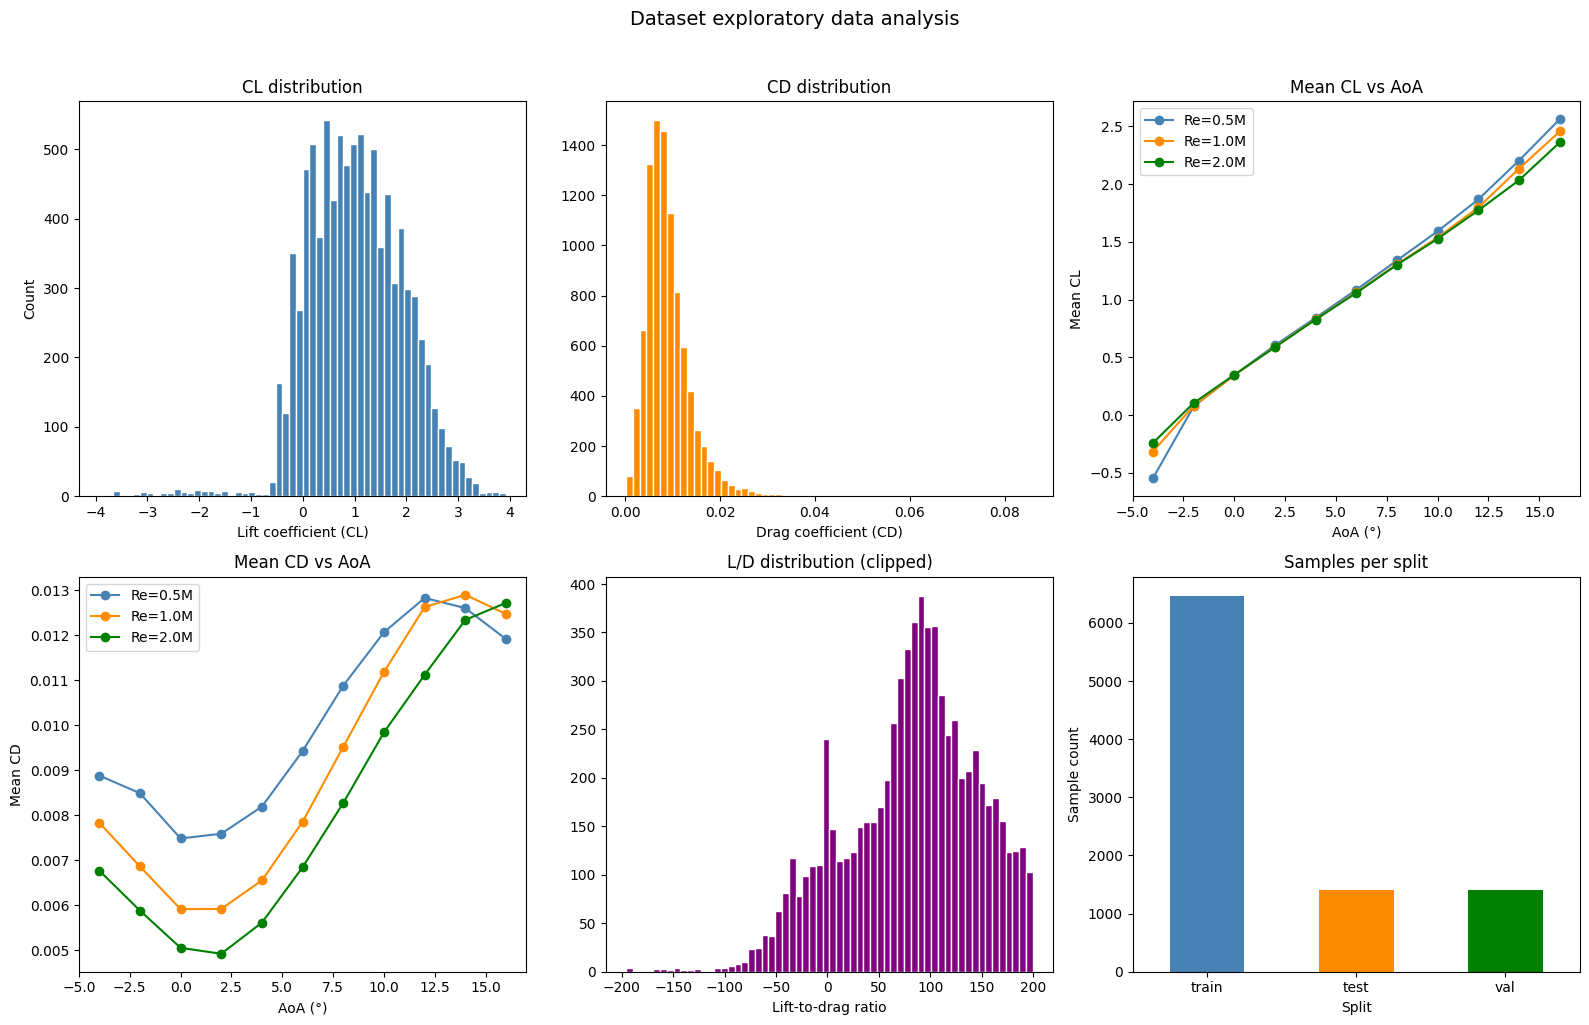

EDA plots saved.


In [ ]:
def plot_eda(
    df: pd.DataFrame,
    split_counts: pd.Series,
    re_values: list[float] = _RE_VALUES,
    save_path: Path | None = None,
) -> None:
    """Generate a 2×3 EDA figure for the labeled dataset.

    Args:
        df: Full labeled DataFrame with columns CL, CD, LD_ratio, aoa, reynolds.
        split_counts: Series of sample counts per split (from value_counts()).
        re_values: Reynolds numbers used in the sweep (for legend labels)
        save_path: If provided, save the figure to this path.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    colors = ['steelblue', 'darkorange', 'green']

    axes[0, 0].hist(df['CL'], bins=60, color='steelblue', edgecolor='white', lw=0.5)
    axes[0, 0].set(xlabel='Lift coefficient (CL)', ylabel='Count', title='CL distribution')

    axes[0, 1].hist(df['CD'], bins=60, color='darkorange', edgecolor='white', lw=0.5)
    axes[0, 1].set(xlabel='Drag coefficient (CD)', title='CD distribution')

    for re_val, color in zip(re_values, colors):
        means = df[df['reynolds'] == re_val].groupby('aoa')['CL'].mean()
        axes[0, 2].plot(means.index, means.values, 'o-', color=color,
                        label=f'Re={re_val / 1e6:.1f}M')
    axes[0, 2].set(xlabel='AoA (°)', ylabel='Mean CL', title='Mean CL vs AoA')
    axes[0, 2].legend()

    for re_val, color in zip(re_values, colors):
        means = df[df['reynolds'] == re_val].groupby('aoa')['CD'].mean()
        axes[1, 0].plot(means.index, means.values, 'o-', color=color,
                        label=f'Re={re_val / 1e6:.1f}M')
    axes[1, 0].set(xlabel='AoA (°)', ylabel='Mean CD', title='Mean CD vs AoA')
    axes[1, 0].legend()

    ld = df['LD_ratio'].dropna()
    ld_clipped = ld[(ld > -200) & (ld < 200)]
    axes[1, 1].hist(ld_clipped, bins=60, color='purple', edgecolor='white', lw=0.5)
    axes[1, 1].set(xlabel='Lift-to-drag ratio', title='L/D distribution (clipped)')

    split_counts.plot(kind='bar', ax=axes[1, 2], color=colors)
    axes[1, 2].set(xlabel='Split', ylabel='Sample count', title='Samples per split')
    axes[1, 2].tick_params(axis='x', rotation=0)

    plt.suptitle('Dataset exploratory data analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_eda(_df, _split_counts, save_path=_OUTPUT_DIR / 'eda_plots.png')
print('EDA plots saved.')


In [ ]:
def save_dataset_stats(
    df: pd.DataFrame,
    split_counts: pd.Series,
    n_converged: int,
    n_failed: int,
    output_path: Path,
) -> dict:
    """Compute and save summary statistics for the paper.

    Args:
        df: Full labeled DataFrame.
        split_counts: Series of sample counts per split
        n_converged: Number of successful XFOIL calls
        n_failed: Number of failed/non-converged XFOIL calls
        output_path: JSON file path to write

    Returns:
        The stats dict that was written to disk.
    """
    total = n_converged + n_failed
    stats = {
        'total_samples': int(len(df)),
        'unique_airfoils': int(df['airfoil_name'].nunique()),
        'train_samples': int(split_counts.get('train', 0)),
        'val_samples': int(split_counts.get('val', 0)),
        'test_samples': int(split_counts.get('test', 0)),
        'aoa_range': [float(df['aoa'].min()), float(df['aoa'].max())],
        'reynolds_values': _RE_VALUES,
        'input_dim': int(2 * _N_POINTS + 2),
        'output_dim': 2,
        'CL_mean': float(df['CL'].mean()),
        'CL_std': float(df['CL'].std()),
        'CD_mean': float(df['CD'].mean()),
        'CD_std': float(df['CD'].std()),
        'xfoil_ncrit': _NCRIT,
        'n_resample_points': _N_POINTS,
        'convergence_rate': f'{n_converged / total * 100:.1f}%' if total else 'N/A',
    }
    with open(output_path, 'w') as f:
        json.dump(stats, f, indent=2)
    return stats


# n_converged / n_failed are not easily retrievable after a resume, so
# derive convergence rate from the dataset size vs theoretical maximum.
_n_theoretical = len(_airfoil_records) * len(_AOA_VALUES) * len(_RE_VALUES)
_n_converged_est = len(_df)
_n_failed_est = _n_theoretical - _n_converged_est

_stats = save_dataset_stats(_df, _split_counts,n_converged=_n_converged_est, n_failed=max(_n_failed_est, 0), output_path=_OUTPUT_DIR / 'dataset_stats.json',)
shutil.copy(_OUTPUT_DIR / 'dataset_stats.json', _DRIVE_DIR / 'dataset_stats.json',)
for k, v in _stats.items():
    print(f'  {k}: {v}')


  total_samples: 9284
  unique_airfoils: 300
  train_samples: 6469
  val_samples: 1405
  test_samples: 1410
  aoa_range: [-4.0, 16.0]
  reynolds_values: [500000, 1000000, 2000000]
  input_dim: 402
  output_dim: 2
  CL_mean: 1.0136232981473503
  CL_std: 0.9148412434142857
  CD_mean: 0.008881473502800517
  CD_std: 0.004650719079997831
  xfoil_ncrit: 9
  n_resample_points: 200
  convergence_rate: 17.7%
